# Установка зависимостей

In [ ]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn ucimlrepo --quiet

# Импорт

In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import ModelCheckpoint, Callback, TensorBoard
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor
from ucimlrepo import fetch_ucirepo, list_available_datasets

# Загрузка данных

In [ ]:
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [ ]:
wine_quality = fetch_ucirepo(name="Wine Quality")
df = pd.DataFrame(wine_quality.data.original)

# Иссделование данных

In [ ]:
print(df.info())
print(df.describe())
print(df['color'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None
       fixed_acidity  volatile_acidity  citric_acid  resid

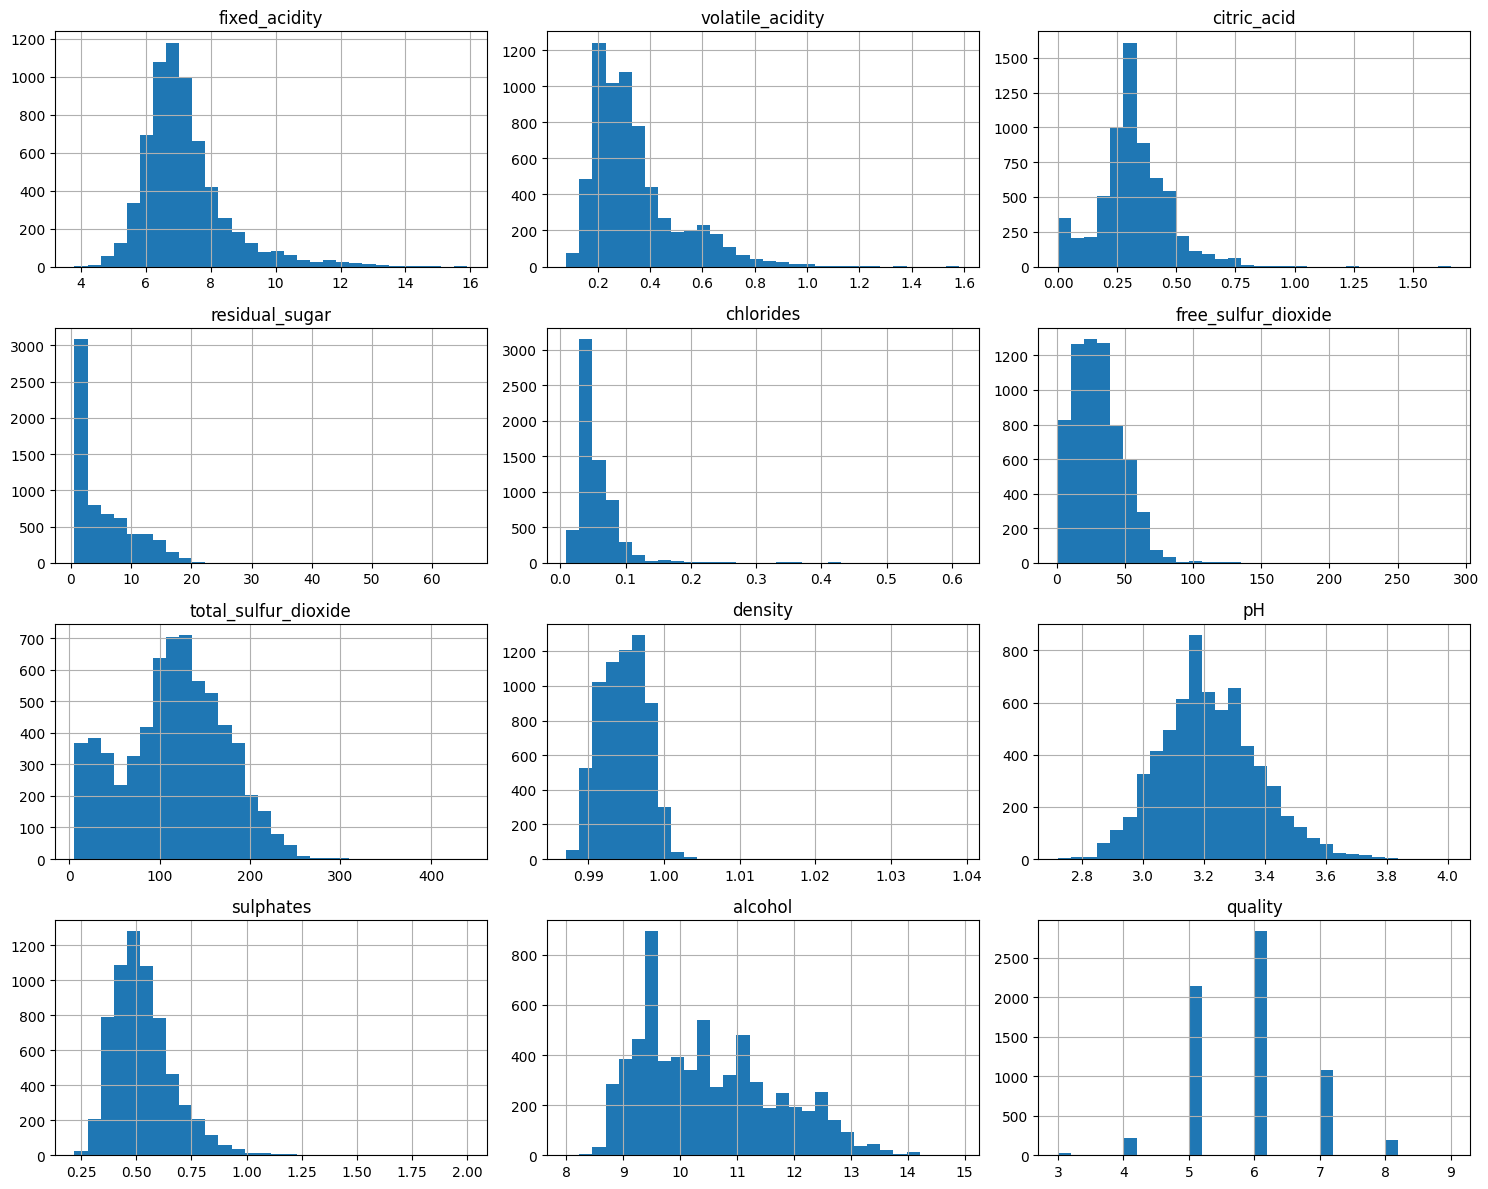

In [ ]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

                      fixed_acidity  volatile_acidity  citric_acid  \
fixed_acidity              1.000000          0.219008     0.324436   
volatile_acidity           0.219008          1.000000    -0.377981   
citric_acid                0.324436         -0.377981     1.000000   
residual_sugar            -0.111981         -0.196011     0.142451   
chlorides                  0.298195          0.377124     0.038998   
free_sulfur_dioxide       -0.282735         -0.352557     0.133126   
total_sulfur_dioxide      -0.329054         -0.414476     0.195242   
density                    0.458910          0.271296     0.096154   
pH                        -0.252700          0.261454    -0.329808   
sulphates                  0.299568          0.225984     0.056197   
alcohol                   -0.095452         -0.037640    -0.010493   
quality                   -0.076743         -0.265699     0.085532   
color_code                -0.486740         -0.653036     0.187397   

                   

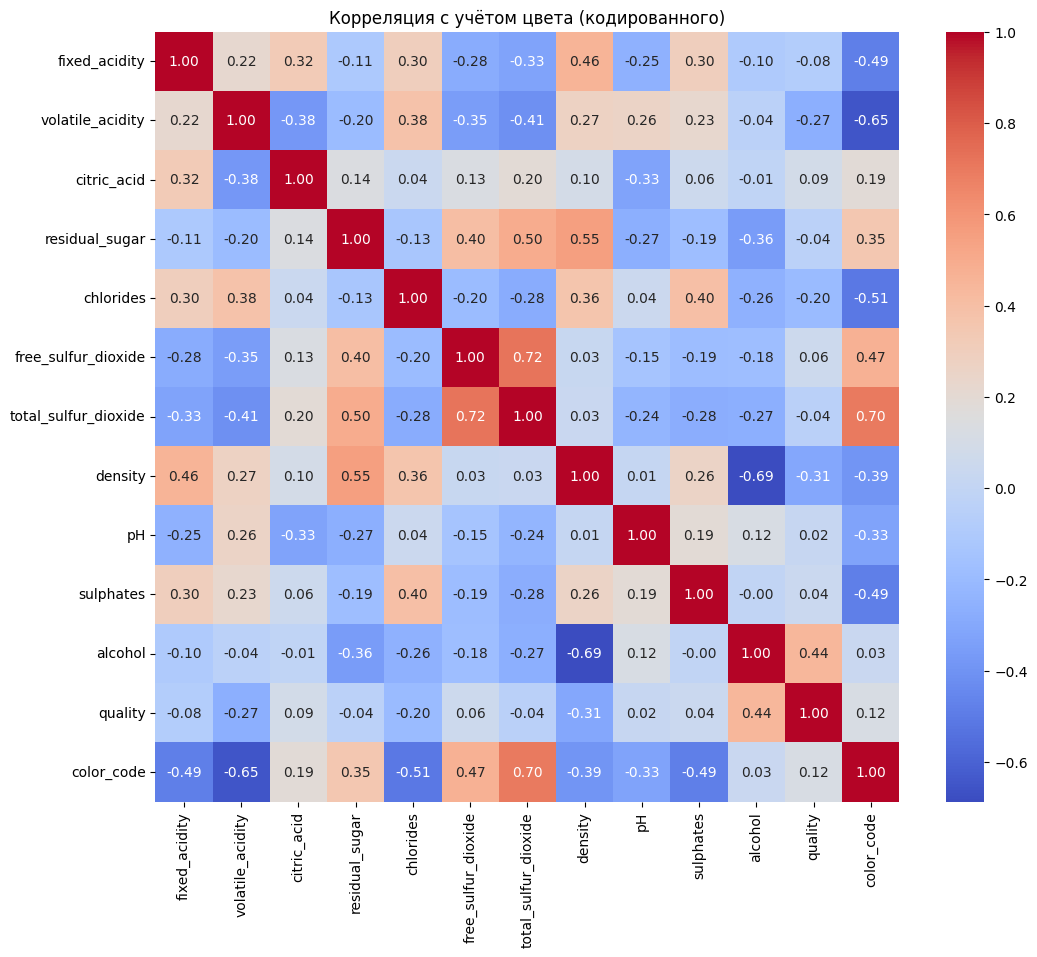

In [ ]:
df['color_code'] = (df['color'] == 'white').astype(int)
corr_with_color = df[['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
                      'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
                      'density', 'pH', 'sulphates', 'alcohol', 'quality', 'color_code']].corr()
print(corr_with_color)
plt.figure(figsize=(12,10))
sns.heatmap(corr_with_color, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция с учётом цвета (кодированного)')
plt.show()

# Предобработка данных

In [ ]:
X = df.drop(['quality', 'color'], axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = X.select_dtypes(include=['float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', ['color_code'])
    ])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

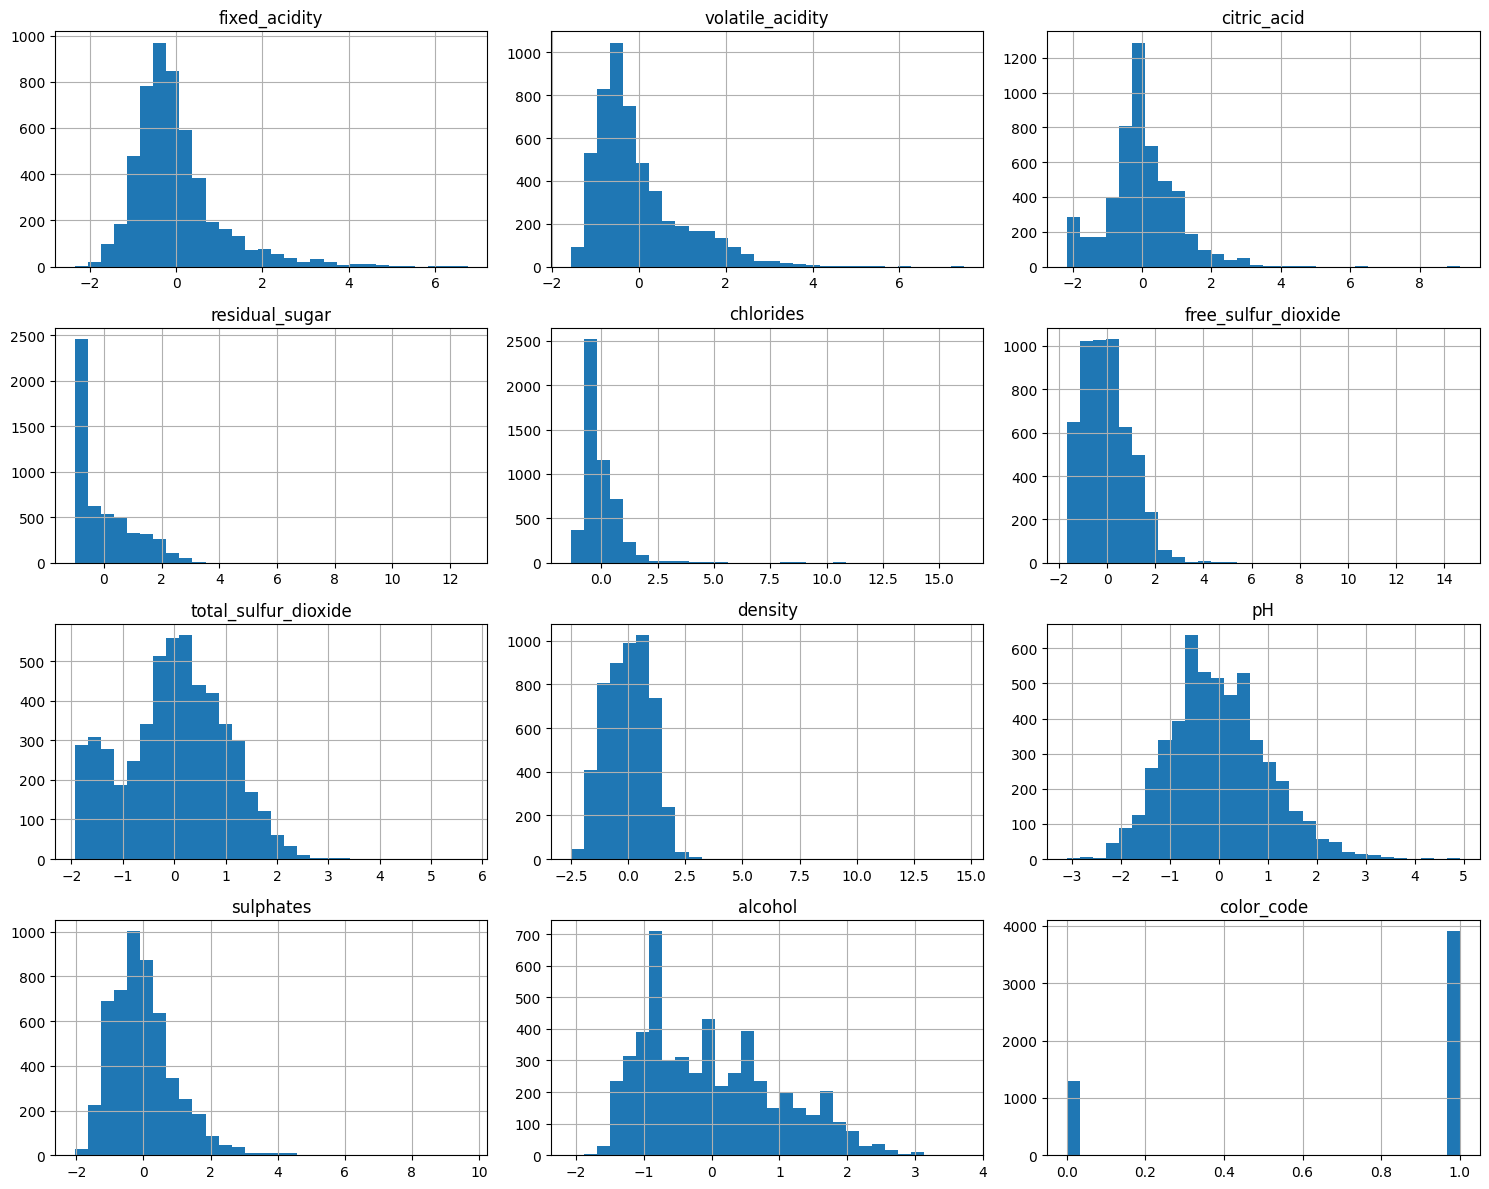

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_scaled_df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

# Генерация модели


In [ ]:
def build_model(input_dim, layers_config, dropout_rates=None, use_batchnorm=False, optimizer='adam'):
    model = keras.Sequential()

    for i, units in enumerate(layers_config):
        if i == 0:
            model.add(layers.Dense(units, activation='relu', input_shape=(input_dim,)))
        else:
            model.add(layers.Dense(units, activation='relu'))

        if use_batchnorm:
            model.add(layers.BatchNormalization())

        if dropout_rates and i < len(dropout_rates):
            if dropout_rates[i] > 0:
                model.add(layers.Dropout(dropout_rates[i]))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

# Обучение и оценка модели

In [ ]:
class BestModelTracker(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_mae = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        val_mae = logs.get('val_mae')

        if val_mae < self.best_val_mae:
            self.best_val_mae = val_mae
            print(f"Epoch {epoch} - New best MAE: {val_mae:.4f}")

In [ ]:
def run_experiment(X_train, y_train, layers_config,
                   dropout_rates, use_batchnorm, optimizer,
                   batch_size, epochs=250):

    model = build_model(
        input_dim=X_train.shape[1],
        layers_config=layers_config,
        dropout_rates=dropout_rates,
        use_batchnorm=use_batchnorm,
        optimizer=optimizer
    )

    early_stop = keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    )
    bmt = BestModelTracker()

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop, bmt]
    )

    best_val_mae = min(history.history['val_mae'])

    return best_val_mae, history

# Исследование

In [ ]:
def grid_search(X_train, y_train):
    architectures = [
        [32, 16],
        [64, 32],
        [128, 64, 32]
    ]
    batchnorm_options = [True, False]
    dropouts = [
        None,
        [0.2, 0.2],
        [0.3, 0.2, 0.1]
    ]
    optimizers = [
      ("Adam", lambda: keras.optimizers.Adam(0.001)),
      ("RMSprop", lambda: keras.optimizers.RMSprop(0.001)),
      ("SGD", lambda: keras.optimizers.SGD(0.01, momentum=0.9))
  ]

    batch_sizes = [16, 32, 64]
    i=0
    results = []
    for arch, drop, (opt_name, opt_fn), batch, bn in itertools.product(architectures, dropouts, optimizers, batch_sizes, batchnorm_options):
        if drop is not None and len(drop) != len(arch):
            continue
        i += 1
        print(f"Test {i}: {arch}, drop={drop}, BN={bn}, "
                  f"{opt_name}, batch={batch}")
        try:
            val_mae, history = run_experiment(
                X_train, y_train,
                layers_config=arch,
                dropout_rates=drop,
                optimizer=opt_fn(),
                batch_size=batch,
                use_batchnorm=bn,
            )
            model_info = {
              "architecture": arch,
              "dropout": drop,
              "batchnorm": bn,
              "optimizer": opt_name,
              "batch_size": batch,
              "val_mae": val_mae,
              "history": history
            }
            results.append(model_info)

            print(f"Done: {arch}, drop={drop}, BN={bn}, "
                  f"{opt_name}, batch={batch} -> MAE={val_mae:.4f}")

        except Exception as e:
            print("Error:", e)

    return pd.DataFrame(results)

In [ ]:
results_df = grid_search(X_train_scaled, y_train)

Test 1: [32, 16], drop=None, BN=True, Adam, batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0 - New best MAE: 3.3626
Epoch 1 - New best MAE: 0.7249
Epoch 2 - New best MAE: 0.6268
Epoch 3 - New best MAE: 0.6077
Epoch 4 - New best MAE: 0.5942
Epoch 6 - New best MAE: 0.5755
Epoch 7 - New best MAE: 0.5703
Epoch 9 - New best MAE: 0.5634
Epoch 11 - New best MAE: 0.5602
Epoch 14 - New best MAE: 0.5583
Epoch 15 - New best MAE: 0.5535
Epoch 17 - New best MAE: 0.5487
Epoch 23 - New best MAE: 0.5486
Epoch 31 - New best MAE: 0.5477
Epoch 32 - New best MAE: 0.5432
Done: [32, 16], drop=None, BN=True, Adam, batch=16 -> MAE=0.5432
Test 2: [32, 16], drop=None, BN=False, Adam, batch=16
Epoch 0 - New best MAE: 0.9804
Epoch 1 - New best MAE: 0.8019
Epoch 2 - New best MAE: 0.6920
Epoch 3 - New best MAE: 0.6489
Epoch 4 - New best MAE: 0.6337
Epoch 5 - New best MAE: 0.6153
Epoch 7 - New best MAE: 0.5945
Epoch 8 - New best MAE: 0.5907
Epoch 9 - New best MAE: 0.5881
Epoch 10 - New best MAE: 0.5847
Epoch 11 - New best MAE: 0.5773
Epoch 12 - New best MAE: 0.5705
Epoch 14 - New best MAE: 0.5667
Ep

In [ ]:
print("Общая статистика")
print(results_df['val_mae'].describe())
print(f"Лучшее MAE: {results_df['val_mae'].min():.4f}")
best_row = results_df.loc[results_df['val_mae'].idxmin()]
print("Лучшие параметры:")
print(best_row[['architecture', 'dropout', 'batchnorm', 'optimizer', 'batch_size', 'val_mae']])

Общая статистика
count    108.000000
mean       0.544737
std        0.009993
min        0.516349
25%        0.538249
50%        0.544157
75%        0.551285
max        0.574313
Name: val_mae, dtype: float64
Лучшее MAE: 0.5163
Лучшие параметры:
architecture    [128, 64, 32]
dropout                  None
batchnorm                True
optimizer             RMSprop
batch_size                 64
val_mae              0.516349
Name: 82, dtype: object


In [ ]:
df_copy = results_df.copy()

# Преобразуем списки в строки для группировки
df_copy['arch_str'] = df_copy['architecture'].apply(str)

# Группируем по архитектуре и выбираем top 10 по val_mae (наименьшие значения)
top10_per_arch = (df_copy.groupby('arch_str', group_keys=False)
                         .apply(lambda x: x.nsmallest(10, 'val_mae'))
                         .reset_index(drop=True))

print("Топ 10 моделей по архитектуре (лучшие MAE):")
print(top10_per_arch[['architecture', 'dropout', 'batchnorm', 'optimizer', 'batch_size', 'val_mae']].to_string())

Топ 10 моделей по архитектуре (лучшие MAE):
     architecture          dropout  batchnorm optimizer  batch_size   val_mae
0   [128, 64, 32]             None       True   RMSprop          64  0.516349
1   [128, 64, 32]             None       True       SGD          32  0.521829
2   [128, 64, 32]             None      False       SGD          64  0.528008
3   [128, 64, 32]             None      False   RMSprop          64  0.528030
4   [128, 64, 32]             None      False       SGD          16  0.529276
5   [128, 64, 32]             None       True      Adam          32  0.529713
6   [128, 64, 32]             None      False   RMSprop          32  0.532651
7   [128, 64, 32]  [0.3, 0.2, 0.1]      False   RMSprop          32  0.532822
8   [128, 64, 32]             None      False      Adam          64  0.533167
9   [128, 64, 32]             None      False       SGD          32  0.534203
10       [32, 16]             None      False       SGD          64  0.536137
11       [32, 16]   

/tmp/ipykernel_2835/4099715158.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(10, 'val_mae'))


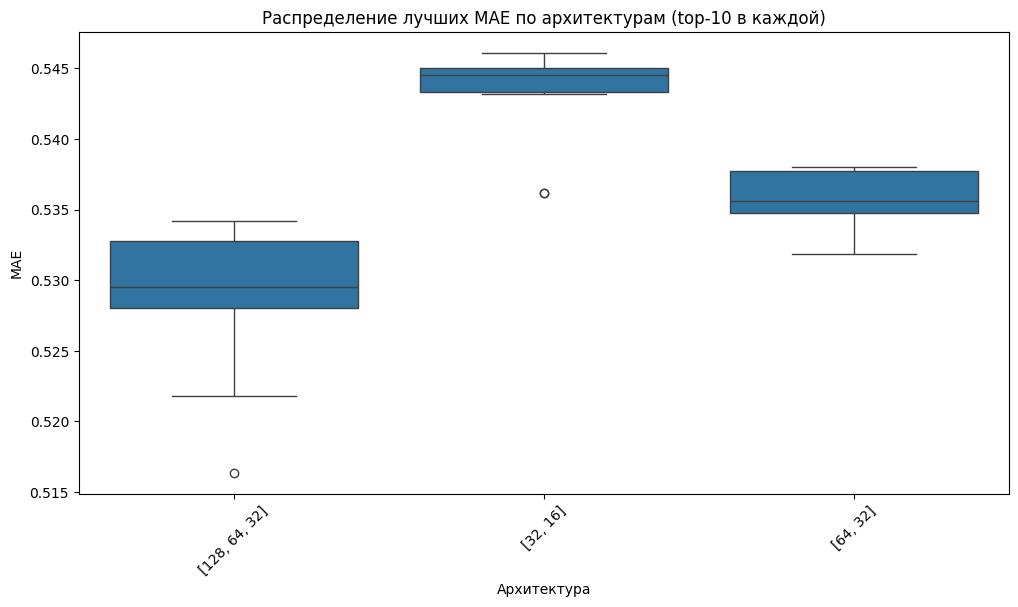

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=top10_per_arch, x='arch_str', y='val_mae', order=sorted(top10_per_arch['arch_str'].unique()))
plt.title('Распределение лучших MAE по архитектурам (top-10 в каждой)')
plt.xlabel('Архитектура')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.show()

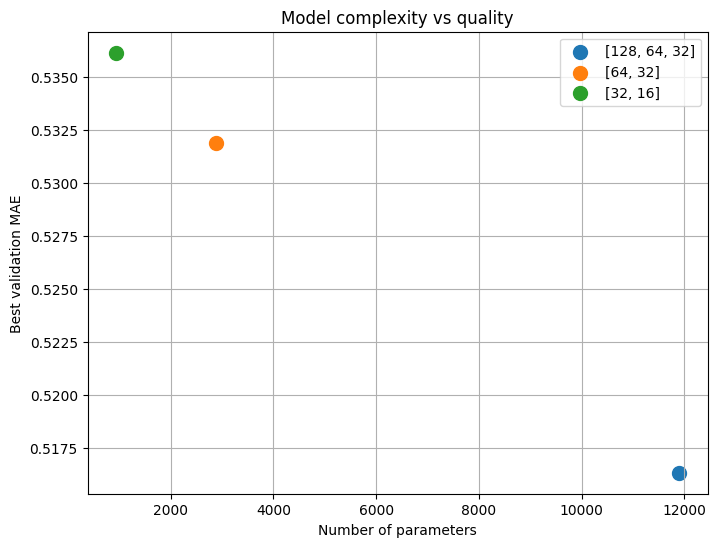

In [ ]:
def count_params(arch):
    n_in = 11
    total = 0
    prev = n_in
    for units in arch:
        total += prev * units + units
        prev = units
    total += prev * 1 + 1  # выходной слой
    return total

# список уникальных архитектур с их лучшими MAE
arch_mae = {
    str([128,64,32]): 0.516349,
    str([64,32]):     0.531867,
    str([32,16]):     0.536137
}

arch_params = {str(arch): count_params(arch) for arch in [[128,64,32], [64,32], [32,16]]}

# график сложность vs качество
fig, ax = plt.subplots(figsize=(8, 6))
for arch_str in arch_mae:
    ax.scatter(arch_params[arch_str], arch_mae[arch_str], s=100, label=arch_str)

ax.set_xlabel('Number of parameters')
ax.set_ylabel('Best validation MAE')
ax.set_title('Model complexity vs quality')
ax.legend()
ax.grid(True)
plt.show()

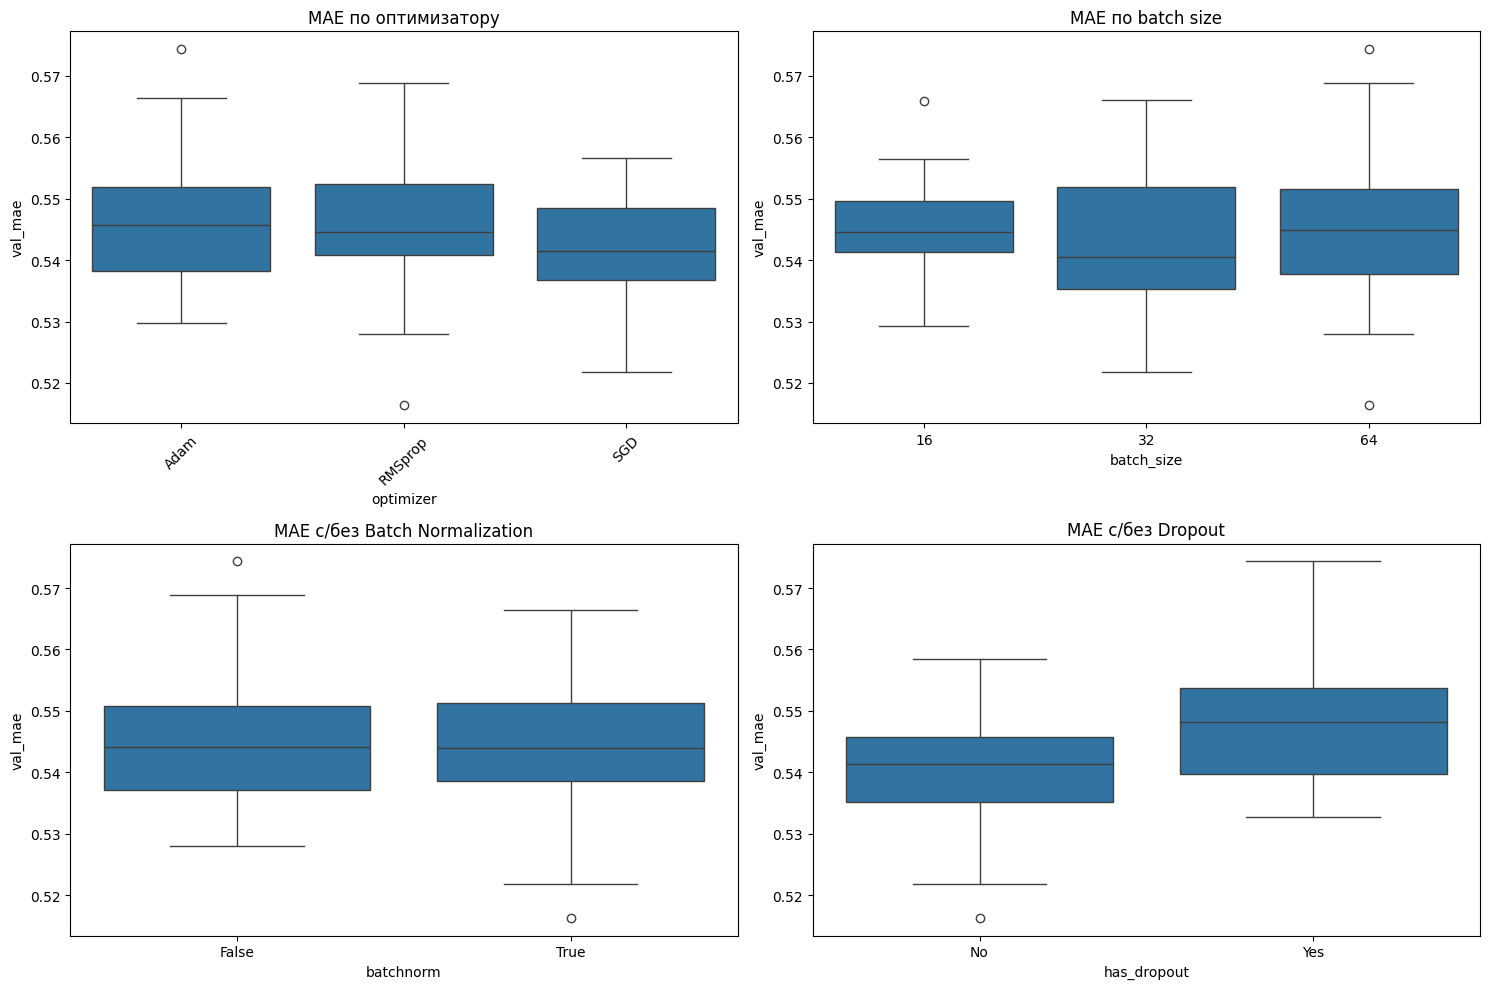

In [ ]:
df_plot = results_df.copy()
df_plot['arch_str'] = df_plot['architecture'].apply(str)
df_plot['dropout_str'] = df_plot['dropout'].apply(lambda x: str(x) if x is not None else 'None')

plt.figure(figsize=(15, 10))

# Влияние оптимизатора
plt.subplot(2, 2, 1)
sns.boxplot(data=df_plot, x='optimizer', y='val_mae')
plt.title('MAE по оптимизатору')
plt.xticks(rotation=45)

# Влияние batch size
plt.subplot(2, 2, 2)
sns.boxplot(data=df_plot, x='batch_size', y='val_mae')
plt.title('MAE по batch size')

# Влияние batch normalization
plt.subplot(2, 2, 3)
sns.boxplot(data=df_plot, x='batchnorm', y='val_mae')
plt.title('MAE с/без Batch Normalization')

# Влияние dropout (есть/нет)
plt.subplot(2, 2, 4)
df_plot['has_dropout'] = df_plot['dropout'].apply(lambda x: 'Yes' if x is not None else 'No')
sns.boxplot(data=df_plot, x='has_dropout', y='val_mae')
plt.title('MAE с/без Dropout')

plt.tight_layout()
plt.show()

In [ ]:
def train_and_evaluate_model(X_train, y_train, X_test, y_test, layers_config,
                             dropout_rates, use_batchnorm, optimizer,
                             batch_size, epochs=250, verbose=0):
    model = build_model(
        input_dim=X_train.shape[1],
        layers_config=layers_config,
        dropout_rates=dropout_rates,
        use_batchnorm=use_batchnorm,
        optimizer=optimizer
    )

    early_stop = keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
    )
    bmt = BestModelTracker()

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[early_stop, bmt]
    )

    # Предсказание на тесте
    y_pred = model.predict(X_test, verbose=0).flatten()
    test_mae = mean_absolute_error(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

    return history, test_mae, test_mse, test_r2

In [ ]:
def run_multiple_trials(X_train, y_train, X_test, y_test, layers_config,
                        dropout_rates, use_batchnorm, optimizer,
                        batch_size, n_trials=10, epochs=250):
    results = []
    for i in range(n_trials):
        print(f"Trial {i+1}/{n_trials}")
        _, test_mae, test_mse, test_r2 = train_and_evaluate_model(
            X_train, y_train, X_test, y_test,
            layers_config, dropout_rates, use_batchnorm, optimizer(),
            batch_size, epochs, verbose=0
        )
        results.append({
            'trial': i+1,
            'test_mae': test_mae,
            'test_mse': test_mse,
            'test_r2': test_r2
        })
    return pd.DataFrame(results)

In [ ]:
optimal_config = {
    'layers_config': [64, 32],
    'dropout_rates': None,
    'use_batchnorm': False,
    'optimizer': lambda: keras.optimizers.SGD(0.01, momentum=0.9),
    'batch_size': 32
}

trials_df = run_multiple_trials(X_train_scaled, y_train, X_test_scaled, y_test,
                                **optimal_config, n_trials=10, epochs=250)

Trial 1/10
Epoch 0 - New best MAE: 0.6081
Epoch 1 - New best MAE: 0.5690
Epoch 2 - New best MAE: 0.5492
Epoch 3 - New best MAE: 0.5440
Epoch 5 - New best MAE: 0.5395
Epoch 8 - New best MAE: 0.5376
Epoch 9 - New best MAE: 0.5327
Epoch 15 - New best MAE: 0.5311
Epoch 18 - New best MAE: 0.5259
Epoch 20 - New best MAE: 0.5221
Trial 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0 - New best MAE: 0.5803
Epoch 1 - New best MAE: 0.5628
Epoch 2 - New best MAE: 0.5512
Epoch 4 - New best MAE: 0.5463
Epoch 7 - New best MAE: 0.5404
Epoch 8 - New best MAE: 0.5356
Epoch 13 - New best MAE: 0.5331
Trial 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0 - New best MAE: 0.5880
Epoch 1 - New best MAE: 0.5662
Epoch 3 - New best MAE: 0.5495
Epoch 4 - New best MAE: 0.5451
Epoch 7 - New best MAE: 0.5447
Epoch 11 - New best MAE: 0.5397
Epoch 12 - New best MAE: 0.5333
Epoch 17 - New best MAE: 0.5318
Trial 4/10


...

Epoch 0 - New best MAE: 0.5878
Epoch 1 - New best MAE: 0.5740
Epoch 2 - New best MAE: 0.5645
Epoch 3 - New best MAE: 0.5548
Epoch 6 - New best MAE: 0.5496
Epoch 7 - New best MAE: 0.5385
Trial 9/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0 - New best MAE: 0.5673
Epoch 1 - New best MAE: 0.5553
Epoch 2 - New best MAE: 0.5530
Epoch 4 - New best MAE: 0.5446
Epoch 8 - New best MAE: 0.5431
Epoch 11 - New best MAE: 0.5380
Epoch 18 - New best MAE: 0.5348
Epoch 23 - New best MAE: 0.5329
Trial 10/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0 - New best MAE: 0.5859
Epoch 1 - New best MAE: 0.5616
Epoch 2 - New best MAE: 0.5547
Epoch 4 - New best MAE: 0.5460
Epoch 6 - New best MAE: 0.5418
Epoch 9 - New best MAE: 0.5408
Epoch 10 - New best MAE: 0.5406
Epoch 16 - New best MAE: 0.5362


        test_mae   test_mse    test_r2
count  10.000000  10.000000  10.000000
mean    0.531019   0.465050   0.390879
std     0.007215   0.009745   0.012764
min     0.520048   0.451977   0.373867
25%     0.525117   0.457523   0.378698
50%     0.531597   0.464038   0.392204
75%     0.536701   0.474349   0.400737
max     0.542231   0.478038   0.408002


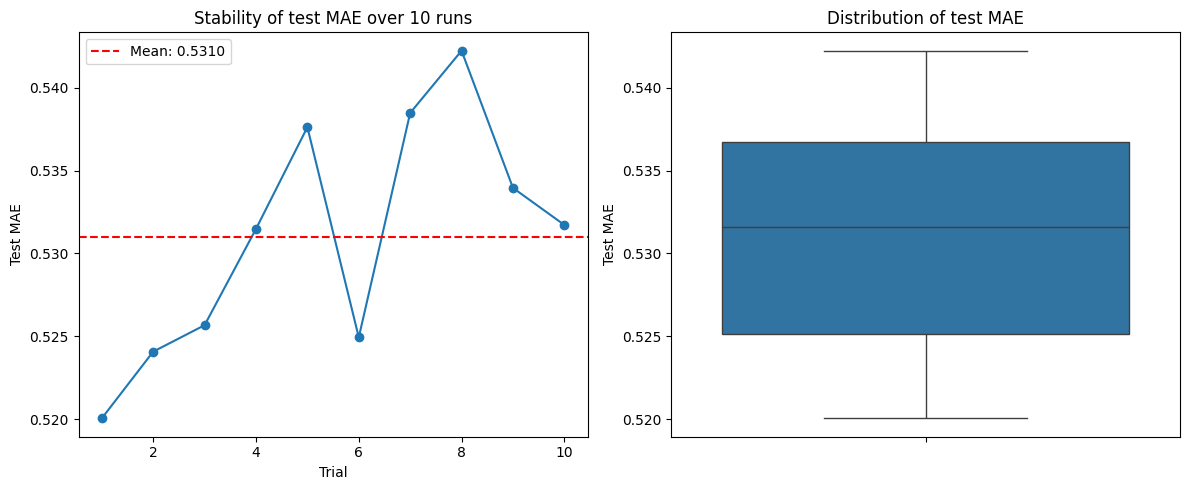

In [ ]:
print(trials_df[['test_mae', 'test_mse', 'test_r2']].describe())

# График разброса тестовых MAE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(trials_df['trial'], trials_df['test_mae'], 'o-')
plt.xlabel('Trial')
plt.ylabel('Test MAE')
plt.title('Stability of test MAE over 10 runs')
plt.axhline(y=trials_df['test_mae'].mean(), color='r', linestyle='--', label=f'Mean: {trials_df["test_mae"].mean():.4f}')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=trials_df['test_mae'])
plt.ylabel('Test MAE')
plt.title('Distribution of test MAE')
plt.tight_layout()
plt.show()

In [ ]:
history, test_mae, test_mse, test_r2 = train_and_evaluate_model(
    X_train_scaled, y_train, X_test_scaled, y_test,
    layers_config=[64, 32],
    dropout_rates= None,
    use_batchnorm=False,
    optimizer=keras.optimizers.SGD(0.01, momentum=0.9),
    batch_size=32,
    epochs=250,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0 - New best MAE: 0.5765
Epoch 2 - New best MAE: 0.5632
Epoch 3 - New best MAE: 0.5591
Epoch 5 - New best MAE: 0.5454
Epoch 8 - New best MAE: 0.5409
Epoch 12 - New best MAE: 0.5374
Epoch 28 - New best MAE: 0.5361


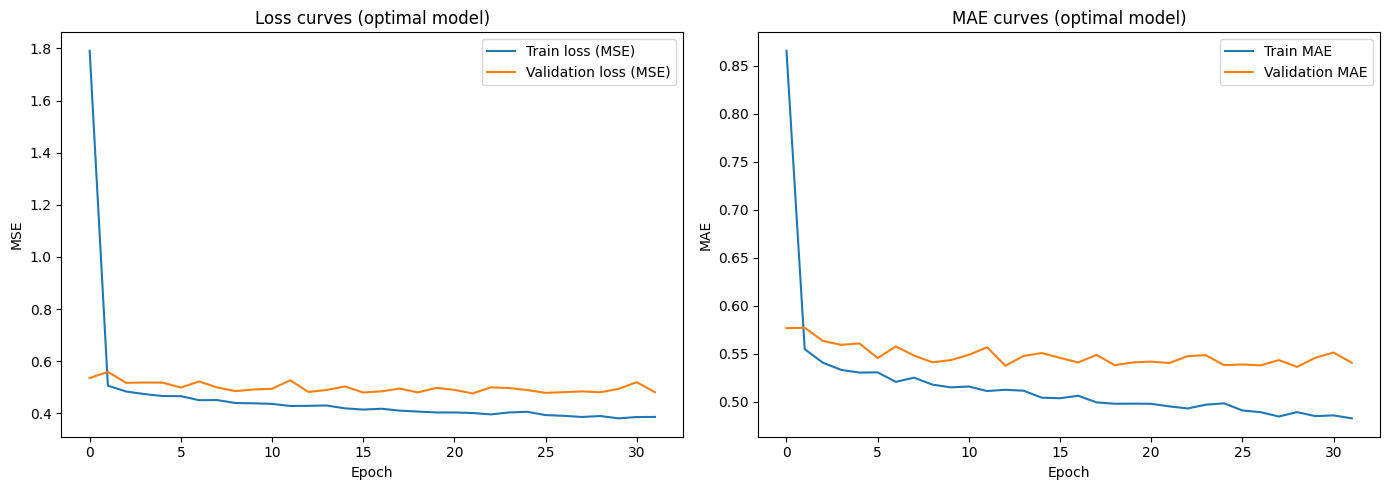

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train loss (MSE)')
ax1.plot(history.history['val_loss'], label='Validation loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.set_title('Loss curves (optimal model)')

ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.set_title('MAE curves (optimal model)')

plt.tight_layout()
plt.show()